# data visualization and analysis using pandas 

## DataFrame in Pandas 

In [18]:
import pandas as pd

df = pd.read_csv('/Users/macos/AIO/module 3 /w1/Thứ 6/code/advertising_simple.csv')
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   TV         8 non-null      int64
 1   Radio      8 non-null      int64
 2   Newspaper  8 non-null      int64
 3   Sales      8 non-null      int64
dtypes: int64(4)
memory usage: 388.0 bytes


In [10]:
df.sort_values('Sales')

,TV,Radio,Newspaper,Sales
7,8,2,1,4
4,8,48,75,7
0,44,39,45,10
5,57,32,23,11
1,17,45,69,12
6,120,19,11,13
2,151,41,58,16
3,180,10,58,17


In [16]:
df.sort_values(['Newspaper', 'Radio'])

,TV,Radio,Newspaper,Sales
7,8,2,1,4
6,120,19,11,13
5,57,32,23,11
0,44,39,45,10
3,180,10,58,17
2,151,41,58,16
1,17,45,69,12
4,8,48,75,7


In [20]:
df['ID'] = [1 , 2 , 3 ,4 , 5, 6, 7, 8]
df

,TV,Radio,Newspaper,Sales,ID
0,44,39,45,10,1
1,17,45,69,12,2
2,151,41,58,16,3
3,180,10,58,17,4
4,8,48,75,7,5
5,57,32,23,11,6
6,120,19,11,13,7
7,8,2,1,4,8


In [22]:
df = df.set_index('ID' , inplace = False)
df

,TV,Radio,Newspaper,Sales
ID,,,,
1,44,39,45,10
2,17,45,69,12
3,151,41,58,16
4,180,10,58,17
5,8,48,75,7
6,57,32,23,11
7,120,19,11,13
8,8,2,1,4


In [24]:
df1 = df.reset_index(drop = True, inplace = False)
df1

,TV,Radio,Newspaper,Sales
0,44,39,45,10
1,17,45,69,12
2,151,41,58,16
3,180,10,58,17
4,8,48,75,7
5,57,32,23,11
6,120,19,11,13
7,8,2,1,4


inplace là một tham số quan trọng được sử dụng trong nhiều pp để xác định cách thay đổi dữ liệu 

- Trả về một DataFrame/Series mới (khi inplace=False)
- Thay đổi trực tiếp trên đối tượng gốc (khi inplace=True)

----

In [26]:
import pandas as pd
import numpy as np 
import seaborn as sn
import matplotlib.pyplot as plt 

df = pd.read_csv('/Users/macos/AIO/module 3 /w1/Thứ 6/code/example1/WeatherHistory2D.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Formatted Date   96453 non-null  object 
 1   Temperature (C)  96453 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.5+ MB


In [28]:
datetime = pd.to_datetime('2006-07-25 00:00:00.000' , utc = False)
print(datetime)
print(datetime.year)
print(datetime.month)
print(datetime.day)

2006-07-25 00:00:00
2006
7
25


In [29]:
df

,Formatted Date,Temperature (C)
0,2006-01-01 00:00:00.000 +0100,0.577778
1,2006-01-01 01:00:00.000 +0100,1.161111
2,2006-01-01 02:00:00.000 +0100,1.666667
3,2006-01-01 03:00:00.000 +0100,1.711111
4,2006-01-01 04:00:00.000 +0100,1.183333
...,...,...
96448,2016-12-31 19:00:00.000 +0100,0.488889
96449,2016-12-31 20:00:00.000 +0100,0.072222
96450,2016-12-31 21:00:00.000 +0100,-0.233333
96451,2016-12-31 22:00:00.000 +0100,-0.472222


In [30]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'] , utc = True)
df

,Formatted Date,Temperature (C)
0,2005-12-31 23:00:00+00:00,0.577778
1,2006-01-01 00:00:00+00:00,1.161111
2,2006-01-01 01:00:00+00:00,1.666667
3,2006-01-01 02:00:00+00:00,1.711111
4,2006-01-01 03:00:00+00:00,1.183333
...,...,...
96448,2016-12-31 18:00:00+00:00,0.488889
96449,2016-12-31 19:00:00+00:00,0.072222
96450,2016-12-31 20:00:00+00:00,-0.233333
96451,2016-12-31 21:00:00+00:00,-0.472222


In [34]:
df['Year'] = df['Formatted Date'].dt.year
df['Month'] = df['Formatted Date'].dt.month
df['Day'] = df['Formatted Date'].dt.day 
df['Hour'] = df['Formatted Date'].dt.hour 
df 

,Formatted Date,Temperature (C),Year,Month,Day,Hour
0,2005-12-31 23:00:00+00:00,0.577778,2005,12,31,23
1,2006-01-01 00:00:00+00:00,1.161111,2006,1,1,0
2,2006-01-01 01:00:00+00:00,1.666667,2006,1,1,1
3,2006-01-01 02:00:00+00:00,1.711111,2006,1,1,2
4,2006-01-01 03:00:00+00:00,1.183333,2006,1,1,3
...,...,...,...,...,...,...
96448,2016-12-31 18:00:00+00:00,0.488889,2016,12,31,18
96449,2016-12-31 19:00:00+00:00,0.072222,2016,12,31,19
96450,2016-12-31 20:00:00+00:00,-0.233333,2016,12,31,20
96451,2016-12-31 21:00:00+00:00,-0.472222,2016,12,31,21


In [38]:
df = df.drop('Formatted Date' , axis = 1)
df

,Temperature (C),Year,Month,Day,Hour
0,0.577778,2005,12,31,23
1,1.161111,2006,1,1,0
2,1.666667,2006,1,1,1
3,1.711111,2006,1,1,2
4,1.183333,2006,1,1,3
...,...,...,...,...,...
96448,0.488889,2016,12,31,18
96449,0.072222,2016,12,31,19
96450,-0.233333,2016,12,31,20
96451,-0.472222,2016,12,31,21


In [ ]:
# delete a row 
df.drop(,axis = 0)
df.drop(,axis = 1)

## example 2 

In [45]:
import pandas as pd
import numpy as np 

df = pd.read_csv('/Users/macos/AIO/module 3 /w1/Thứ 6/code/example2/train.csv')
df

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [48]:
df.drop(["id" , "keyword" , "location"] , axis = 1)

,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...
7608,Two giant cranes holding a bridge collapse int...,1
7609,@aria_ahrary @TheTawniest The out of control w...,1
7610,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,Police investigating after an e-bike collided ...,1


- LƯU Ý : hầu hết các phương thức trong lib pandas đều không làm ảnh hưởng đến DataFrame gốc , nó chỉ tạo ra bản copy thực hiện phương thức đó 

In [51]:
# get values 
print(df[1:2])
print(df[1:4])
print(df[4:])

   id keyword location                                    text  target
1   4     NaN      NaN  Forest fire near La Ronge Sask. Canada       1
   id keyword location                                               text  \
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   

   target  
1       1  
2       1  
3       1  
         id keyword location  \
4         7     NaN      NaN   
5         8     NaN      NaN   
6        10     NaN      NaN   
7        13     NaN      NaN   
8        14     NaN      NaN   
...     ...     ...      ...   
7608  10869     NaN      NaN   
7609  10870     NaN      NaN   
7610  10871     NaN      NaN   
7611  10872     NaN      NaN   
7612  10873     NaN      NaN   

                                                   text  target  
4     Just got sent this photo from Ruby #Alaska a

In [55]:
# df.loc(row , col)
df.loc[1 , 'id']

np.int64(4)

## example 3 

In [56]:
import pandas as pd
import numpy as np 

df = pd.read_csv('/Users/macos/AIO/module 3 /w1/Thứ 6/code/weatherHistory_simple.csv')
df

,Precip Type,Temperature (C)
0,rain,12.2
1,rain,13.8
2,rain,14.7
3,rain,13.8
4,rain,12.7
5,rain,0.5
6,snow,-0.4
7,snow,-1.1
8,snow,-1.6
9,snow,-2.1


In [57]:
df.groupby('Precip Type').mean()

,Temperature (C)
Precip Type,
rain,11.283333
snow,-1.300000


In [61]:
df['Temperature (F)'] = df['Temperature (C)'] * 9/5 + 32
df

,Precip Type,Temperature (C),Temperature (F)
0,rain,12.2,53.96
1,rain,13.8,56.84
2,rain,14.7,58.46
3,rain,13.8,56.84
4,rain,12.7,54.86
5,rain,0.5,32.90
6,snow,-0.4,31.28
7,snow,-1.1,30.02
8,snow,-1.6,29.12
9,snow,-2.1,28.22


## credit card fraud detection 

In [62]:
import pandas as pd
import numpy as np 

df = pd.read_csv('/Users/macos/AIO/module 3 /w1/Thứ 6/code/example3/creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [66]:
df.groupby('Class').size() 

Class
0    284315
1       492
dtype: int64

- loc for indexing by labels 
- iloc for indexing by positional index 

In [67]:
df.iloc[1 , 4]

np.float64(0.448154078460911)

# visualization 

In [72]:
import pandas as pd
import numpy as np 
import seaborn as sns

data = pd.read_csv('/Users/macos/AIO/module 3 /w1/Thứ 6/code/advertising_simple.csv')
data 

,TV,Radio,Newspaper,Sales
0,44,39,45,10
1,17,45,69,12
2,151,41,58,16
3,180,10,58,17
4,8,48,75,7
5,57,32,23,11
6,120,19,11,13
7,8,2,1,4


In [70]:
data.describe()

,TV,Radio,Newspaper,Sales
count,8.000000,8.000000,8.000000,8.000000
mean,73.125000,29.500000,42.500000,11.250000
std,68.059716,17.146428,27.619869,4.334249
min,8.000000,2.000000,1.000000,4.000000
25%,14.750000,16.750000,20.000000,9.250000
50%,50.500000,35.500000,51.500000,11.500000
75%,127.750000,42.000000,60.750000,13.750000
max,180.000000,48.000000,75.000000,17.000000


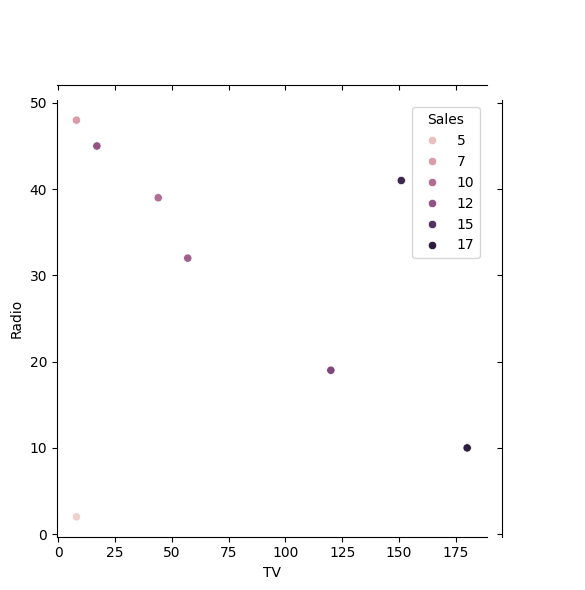

In [74]:
sns.jointplot(x = 'TV' , y = 'Radio' , data = data , hue = 'Sales')
plt.show() 

- scatter plot : biểu đồ phân tán 

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv('/Users/macos/AIO/module 3 /w1/Thứ 6/code/case_study_2/advertising.csv')
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


<Axes: xlabel='TV', ylabel='Sales'>

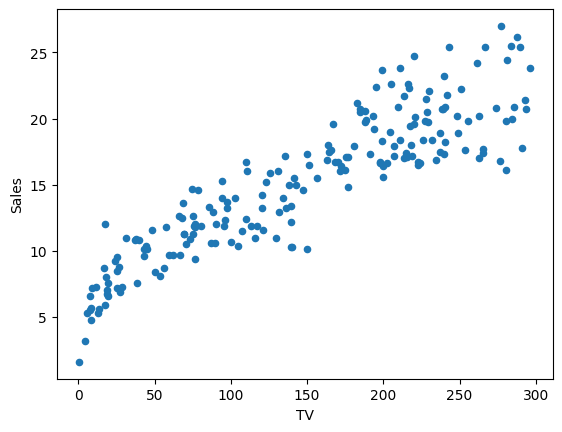

In [77]:
df.plot(x = 'TV' , y = 'Sales' , kind = 'scatter')

<Axes: xlabel='Radio', ylabel='Sales'>

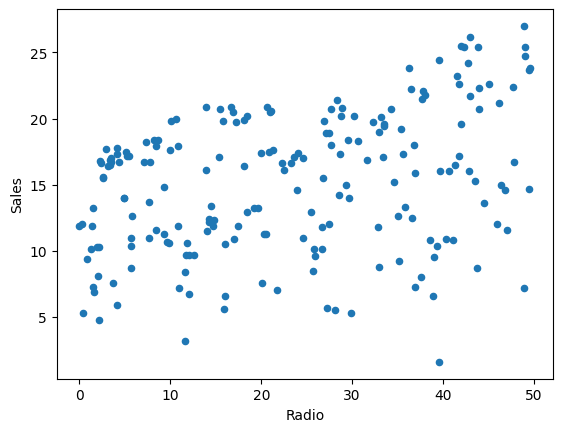

In [78]:
df.plot(x = 'Radio' , y = 'Sales' , kind = 'scatter')

<Axes: xlabel='Newspaper', ylabel='Sales'>

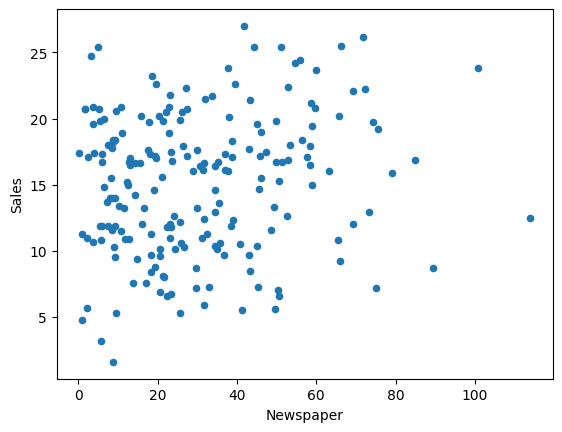

In [79]:
df.plot(x = 'Newspaper' , y = 'Sales' , kind = 'scatter')

In [80]:
df.describe() 

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


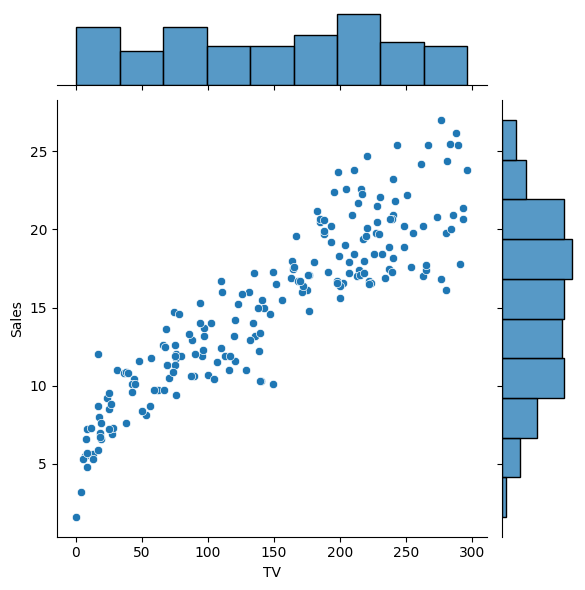

In [82]:
sns.jointplot(x = 'TV', y = 'Sales' , data = df)